In [8]:
import rasterio
from rasterio import features, warp
import json
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration des chemins selon ton arborescence
RAW_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'
os.makedirs(PROCESSED_PATH, exist_ok=True)

image_path = os.path.join(RAW_PATH, 'sample_post_event_0_15_63.tif')
geojson_path = os.path.join(RAW_PATH, 'sample_mask_0_15_63.geojson')

In [9]:
# 1. Lecture de l'image et du CRS
with rasterio.open(image_path) as src:
    img_crs = src.crs
    img_shape = src.shape
    img_transform = src.transform
    image_data = src.read() 

# 2. Chargement et Reprojection du GeoJSON
with open(geojson_path) as f:
    gj = json.load(f)

geoms_reprojected = []
for feature in gj['features']:
    # Transformation des coordonnées vers le système de l'image
    reprojected_geom = warp.transform_geom('EPSG:4326', img_crs, feature['geometry'])
    geoms_reprojected.append(reprojected_geom)

# 3. Création du masque binaire
mask = features.rasterize(geoms_reprojected, out_shape=img_shape, transform=img_transform)

print(f"Rasterisation terminée. Pixels cibles détectés : {np.sum(mask)}")

Rasterisation terminée. Pixels cibles détectés : 42802


In [10]:
# Normalisation (Cast en float32 pour l'IA)
image_normalized = image_data.astype('float32') / 255.0

# On passe du format (Bandes, H, W) au format (H, W, Bandes) pour le traitement
image_normalized = np.moveaxis(image_normalized, 0, -1)

print(f"Forme de l'image normalisée : {image_normalized.shape}")

Forme de l'image normalisée : (1742, 1743, 3)


In [11]:
def get_processed_dataset(img, msk, patch_size=256, min_info=0.01):
    """Découpe en patches et filtre les zones 100% vides."""
    patches_img = []
    patches_msk = []
    
    h, w, c = img.shape
    
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            p_img = img[i:i+patch_size, j:j+patch_size, :]
            p_msk = msk[i:i+patch_size, j:j+patch_size]
            
            # Calcul du pourcentage de pixels blancs dans le masque
            info_ratio = np.sum(p_msk) / (patch_size * patch_size)
            
            # On ne garde que si le patch contient un minimum d'objets
            if info_ratio > 0:
                patches_img.append(p_img)
                patches_msk.append(p_msk)
                
    return np.array(patches_img), np.array(patches_msk)

# Génération du dataset final
X, Y = get_processed_dataset(image_normalized, mask)

print(f"Nombre de patches riches conservés : {len(X)} / 36")

Nombre de patches riches conservés : 11 / 36


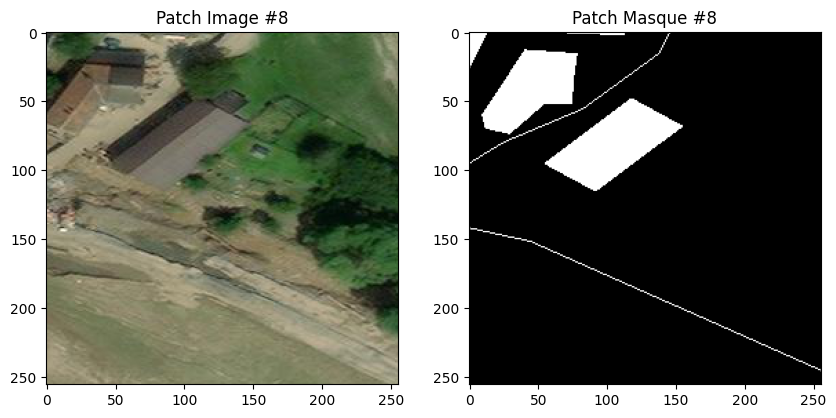

In [12]:
import random

if len(X) > 0:
    idx = random.randint(0, len(X) - 1)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(X[idx][:,:,:3]) # RGB
    plt.title(f"Patch Image #{idx}")
    
    plt.subplot(1, 2, 2)
    plt.imshow(Y[idx], cmap='gray')
    plt.title(f"Patch Masque #{idx}")
    plt.show()
else:
    print("Aucun patch riche trouvé. Vérifiez l'alignement.")

In [13]:
np.save(os.path.join(PROCESSED_PATH, 'X_train_sample.npy'), X)
np.save(os.path.join(PROCESSED_PATH, 'Y_train_sample.npy'), Y)

print("Dataset sauvegardé avec succès dans /data/processed/")

Dataset sauvegardé avec succès dans /data/processed/
